## Salary analysis using ML models

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
import plot_utils  #  --> Here font sizes etc. are defined  

### Import the data

In [2]:
df = pd.read_csv("../data/simulated_salaries.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   25000 non-null  int64  
 1   name                 25000 non-null  str    
 2   sex                  25000 non-null  str    
 3   age                  25000 non-null  int64  
 4   white                25000 non-null  bool   
 5   degree               25000 non-null  bool   
 6   work_area            25000 non-null  str    
 7   years_of_experience  25000 non-null  int64  
 8   salary               25000 non-null  float64
dtypes: bool(2), float64(1), int64(3), str(3)
memory usage: 1.4 MB


## Salary distribution plot - gender

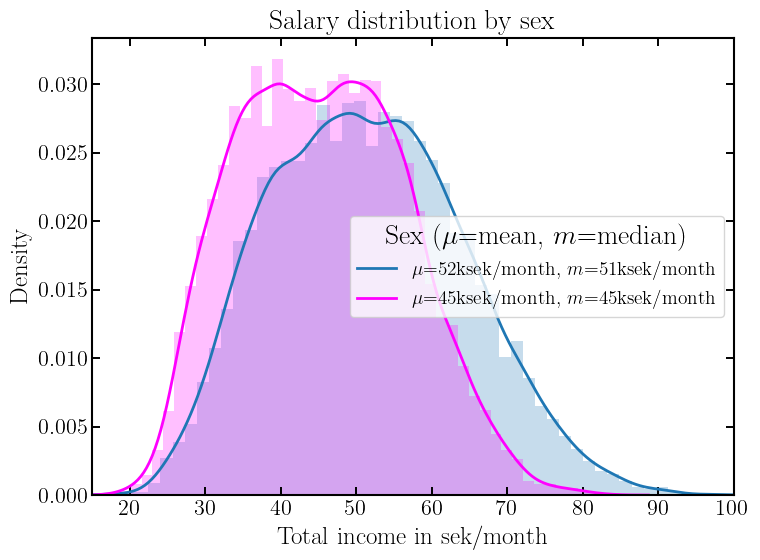

In [3]:
male_salaries = df[df['sex'] == "M"]['salary']
female_salaries = df[df['sex'] == "F"]['salary']

plt.figure(figsize=(8, 6))

colors = ["C0", "magenta"]

# Plot histogram 
plt.hist(male_salaries, bins="fd", density=True, alpha=0.25, color=colors[0])
plt.hist(female_salaries, bins="fd", density=True, alpha=0.25, color=colors[1])

# Plot KDE and legend with information
kde_line_m = sns.kdeplot(male_salaries, 
                         color=colors[0], 
                         linewidth=2, 
                         label=f"$\mu$={male_salaries.mean():.0f}ksek/month, $m$={male_salaries.median():.0f}ksek/month"
                         )
kde_line_f = sns.kdeplot(female_salaries, 
                         color=colors[1], 
                         linewidth=2, 
                         label=f"$\mu$={female_salaries.mean():.0f}ksek/month, $m$={female_salaries.median():.0f}ksek/month"
                         )

plt.xlim(15, 100)

plt.xlabel("Total income in sek/month")
plt.ylabel("Density")
plt.title("Salary distribution by sex")
plt.legend(title="Sex ($\mu$=mean, $m$=median)", loc='best')
plt.tight_layout()
plt.show()

### Salary distribution - work areas

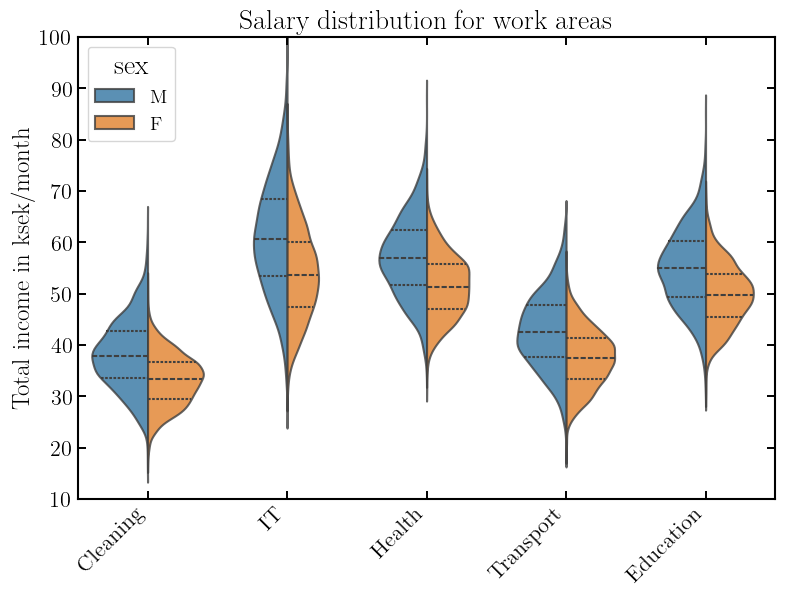

In [4]:
# Make the plot
plt.figure(figsize=(9,6))

sns.violinplot(
    data=df,
    x='work_area',
    y='salary',    
    hue='sex',
    split=True,
    inner='quartile',
    linewidth=1.5,
    alpha=0.8
)

plt.ylim(10, 100)
plt.xticks(rotation=45, ha='right')
plt.title("Salary distribution for work areas")
plt.ylabel("Total income in ksek/month")
plt.xlabel("")
plt.show()

### Salary versus job experience and degree

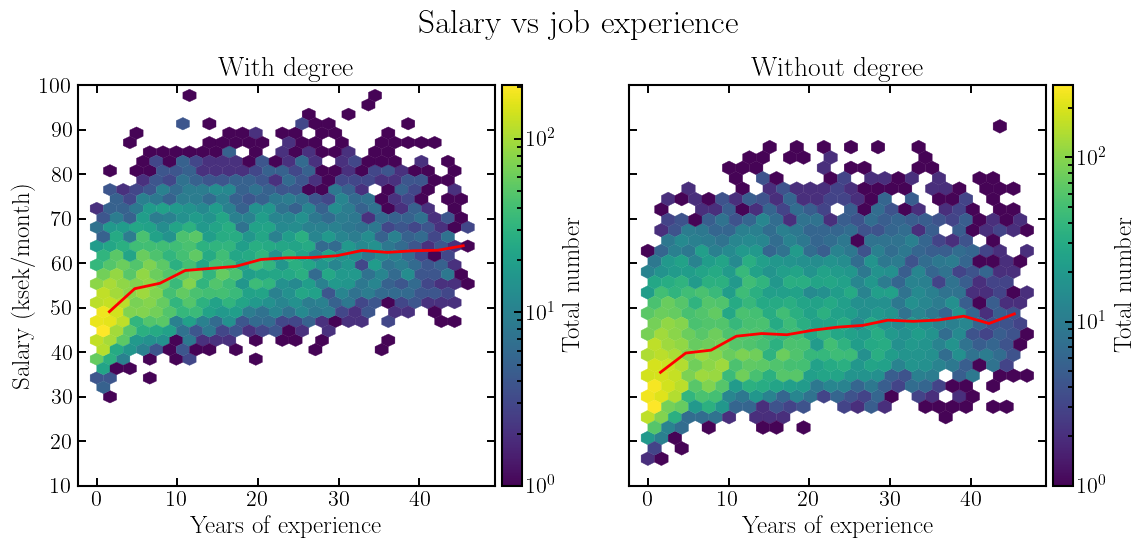

In [5]:
df_degree = df[df['degree']==True].copy()
df_nodegree = df[df['degree']==False].copy()

# bins in experience for median curve
max_x = df['years_of_experience'].max()
bins = np.linspace(0, max_x, 16)
centers = 0.5 * (bins[:-1] + bins[1:])


fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex=True, sharey=True)

# =========================
# LEFT: with degree
# =========================
hb1 = axes[0].hexbin(
    df_degree['years_of_experience'],
    df_degree['salary'],
    gridsize=28,
    cmap='viridis',
    bins='log',
    alpha=0.99,
    edgecolors='face',
    linewidths=0.25
)

axes[0].set_ylim(10, 100)
axes[0].set_title("With degree")
axes[0].set_xlabel("Years of experience")
axes[0].set_ylabel("Salary (ksek/month)")

cb1 = fig.colorbar(hb1, ax=axes[0], pad=0.015)
cb1.set_label("Total number")

median_income_degree = [
    df_degree['salary'][(df_degree['years_of_experience'] >= bins[i]) &
             (df_degree['years_of_experience'] < bins[i+1])].median()
    for i in range(len(bins)-1)
]
axes[0].plot(centers, median_income_degree, color='red', lw=2, label='Median trend')

# =========================
# RIGHT: without degree
# =========================

hb2 = axes[1].hexbin(
    df_nodegree['years_of_experience'],
    df_nodegree['salary'],
    gridsize=28,
    cmap='viridis',
    bins='log',
    alpha=0.99,
    edgecolors='face',
    linewidths=0.25
)

axes[1].set_title("Without degree")
axes[1].set_xlabel("Years of experience")

cb2 = fig.colorbar(hb2, ax=axes[1], pad=0.015)
cb2.set_label("Total number")

median_income_nodegree = [
    df_nodegree['salary'][(df_nodegree['years_of_experience'] >= bins[i]) &
             (df_nodegree['years_of_experience'] < bins[i+1])].median()
    for i in range(len(bins)-1)
]
axes[1].plot(centers, median_income_nodegree, color='red', lw=2, label='Median trend')

fig.suptitle("Salary vs job experience", y=0.93)
plt.tight_layout()
plt.show()

## Prepare data for ML training

#### Define features and target

In [6]:
# Feature types
numerical_features = ['age', 'years_of_experience']
categorical_features = ['name', 'sex', 'work_area', 'white', 'degree']

# Combine
features = numerical_features + categorical_features
target = 'salary'

X = df[features].copy()
y = df[target].copy()

print(f"\nTotal samples: {len(X):,}")
print(f"Target: {target} (in ksek/month)")

print(f"\nNumerical features (scaled):")
for f in numerical_features:
    print(f"  - {f}")

print(f"\nCategorical features (one-hot encoded):")
for f in categorical_features:
    print(f"  - {f}")


Total samples: 25,000
Target: salary (in ksek/month)

Numerical features (scaled):
  - age
  - years_of_experience

Categorical features (one-hot encoded):
  - name
  - sex
  - work_area
  - white
  - degree


#### Preprocessing pipeline

In [7]:
# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {len(X_train):,} rows")
print(f"Test set size: {len(X_test):,} rows")


# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Sanity checks, fitting only for inspection (not for training pipeline usage)
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
ohe = preprocessor.named_transformers_['cat']
n_categorical = len(ohe.get_feature_names_out(categorical_features))
n_numerical = len(numerical_features)

print(f"\nFeature breakdown:")
print(f"  Original features: {X_train.shape[1]}")
print(f"  Numerical features: {n_numerical}")
print(f"  Categorical expanded features: {n_categorical}")
print(f"  Total processed features: {X_train_processed.shape[1]}")
print(f"  Expansion factor: {X_train_processed.shape[1] / X_train.shape[1]:.2f}x")


Training set size: 20,000 rows
Test set size: 5,000 rows

Feature breakdown:
  Original features: 7
  Numerical features: 2
  Categorical expanded features: 23
  Total processed features: 25
  Expansion factor: 3.57x


### Define pipelines for different ML models:
1. Linear
2. Random Forest
3. Gradient Boosting

In [8]:
# Define the models
models = {
    "ridge": Ridge(),
    "rf": RandomForestRegressor(random_state=42),
    "gbr": GradientBoostingRegressor(random_state=42)
}

# Run and store a pipeline for each model
pipelines = {
    name: Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ]).fit(X_train, y_train)
    for name, model in models.items()
}

### Evaluate model performances and compare

In [9]:
results = []

for name, pipe in pipelines.items():

    # Predictions (IMPORTANT: use pipe, not model)
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    # Metrics (train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # Metrics (test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        "Model": name,

        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,

        "Train MAE": train_mae,
        "Test MAE": test_mae,

        "Train R2": train_r2,
        "Test R2": test_r2,

        "Overfit (ΔR2)": train_r2 - test_r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Test RMSE")

display(results_df.round(3))

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Overfit (ΔR2)
2,gbr,5.313,5.476,4.090,4.204,0.813,0.799,0.014
0,ridge,5.841,5.958,4.531,4.623,0.774,0.762,0.012
1,rf,2.549,6.008,1.915,4.638,0.957,0.758,0.198


### Extract feature importance for each model

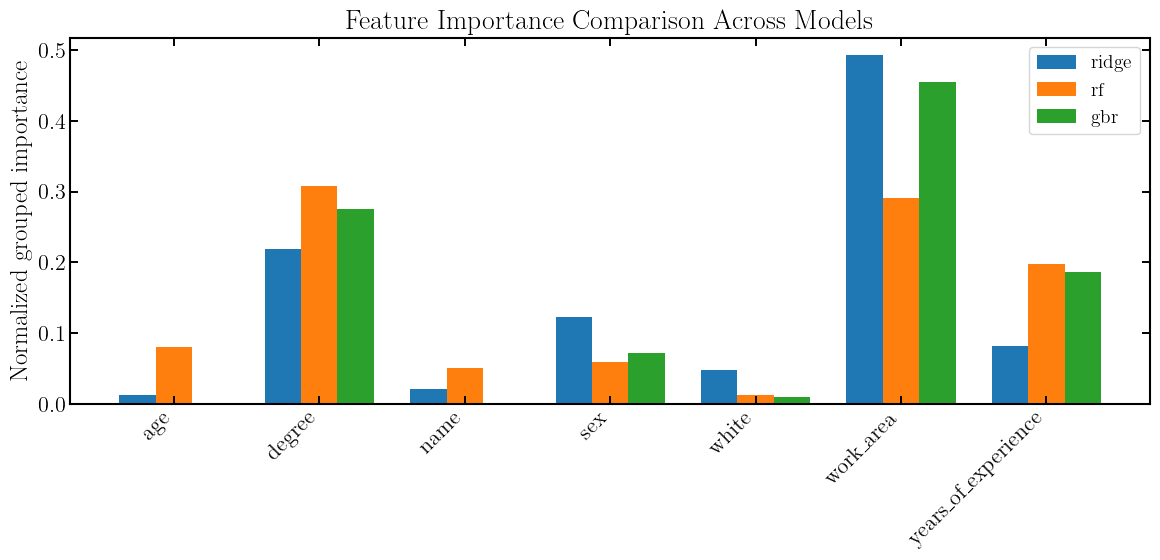

In [10]:
feature_names = preprocessor.get_feature_names_out()

def map_to_base_feature(name):
    if name.startswith("num__"):
        return name.replace("num__", "")

    if name.startswith("cat__"):
        raw = name.replace("cat__", "")

        # collapse one-hot groups
        if raw.startswith("sex"):
            return "sex"
        if raw.startswith("degree"):
            return "degree"
        if raw.startswith("work_area"):
            return "work_area"
        if raw.startswith("white"):
            return "white"
        if raw.startswith("name"):
            return "name"

        return raw

    return name


def get_importance(pipe):
    model = pipe.named_steps["model"]

    # Tree-based models
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_

    # Linear models (Ridge, LinearRegression, Lasso)
    if hasattr(model, "coef_"):
        return np.abs(model.coef_)  # absolute value for importance

    raise ValueError("Model does not support feature importance or coefficients")


def grouped_importance(pipe):
    importances = get_importance(pipe)

    feature_names = pipe.named_steps["preprocess"].get_feature_names_out()

    grouped = {}

    for fname, imp in zip(feature_names, importances):
        base = map_to_base_feature(fname)
        grouped[base] = grouped.get(base, 0) + imp

    df = pd.DataFrame({
        "feature": list(grouped.keys()),
        "importance": list(grouped.values())
    }).sort_values("importance", ascending=False)

    return df


# Make a plot for all 3 models together
importances_dict = {}

for name, pipe in pipelines.items():
    df_imp = grouped_importance(pipe)
    importances_dict[name] = df_imp.set_index("feature")["importance"]

importance_df = pd.DataFrame(importances_dict).fillna(0)

importance_norm = importance_df.copy()
for col in importance_norm.columns:
    importance_norm[col] /= importance_norm[col].sum()

    features = importance_norm.index
x = np.arange(len(features))

width = 0.25  # bar width

plt.figure(figsize=(12,6))

for i, col in enumerate(importance_norm.columns):
    plt.bar(
        x + i * width,
        importance_norm[col],
        width=width,
        label=col
    )

plt.xticks(x + width, features, rotation=45, ha="right")
plt.ylabel("Normalized grouped importance")
plt.title("Feature Importance Comparison Across Models")
plt.legend()

plt.tight_layout()
plt.savefig('../figs/feature_importance_comparison.png', dpi=200)
plt.show()    

### Compare the global model performances

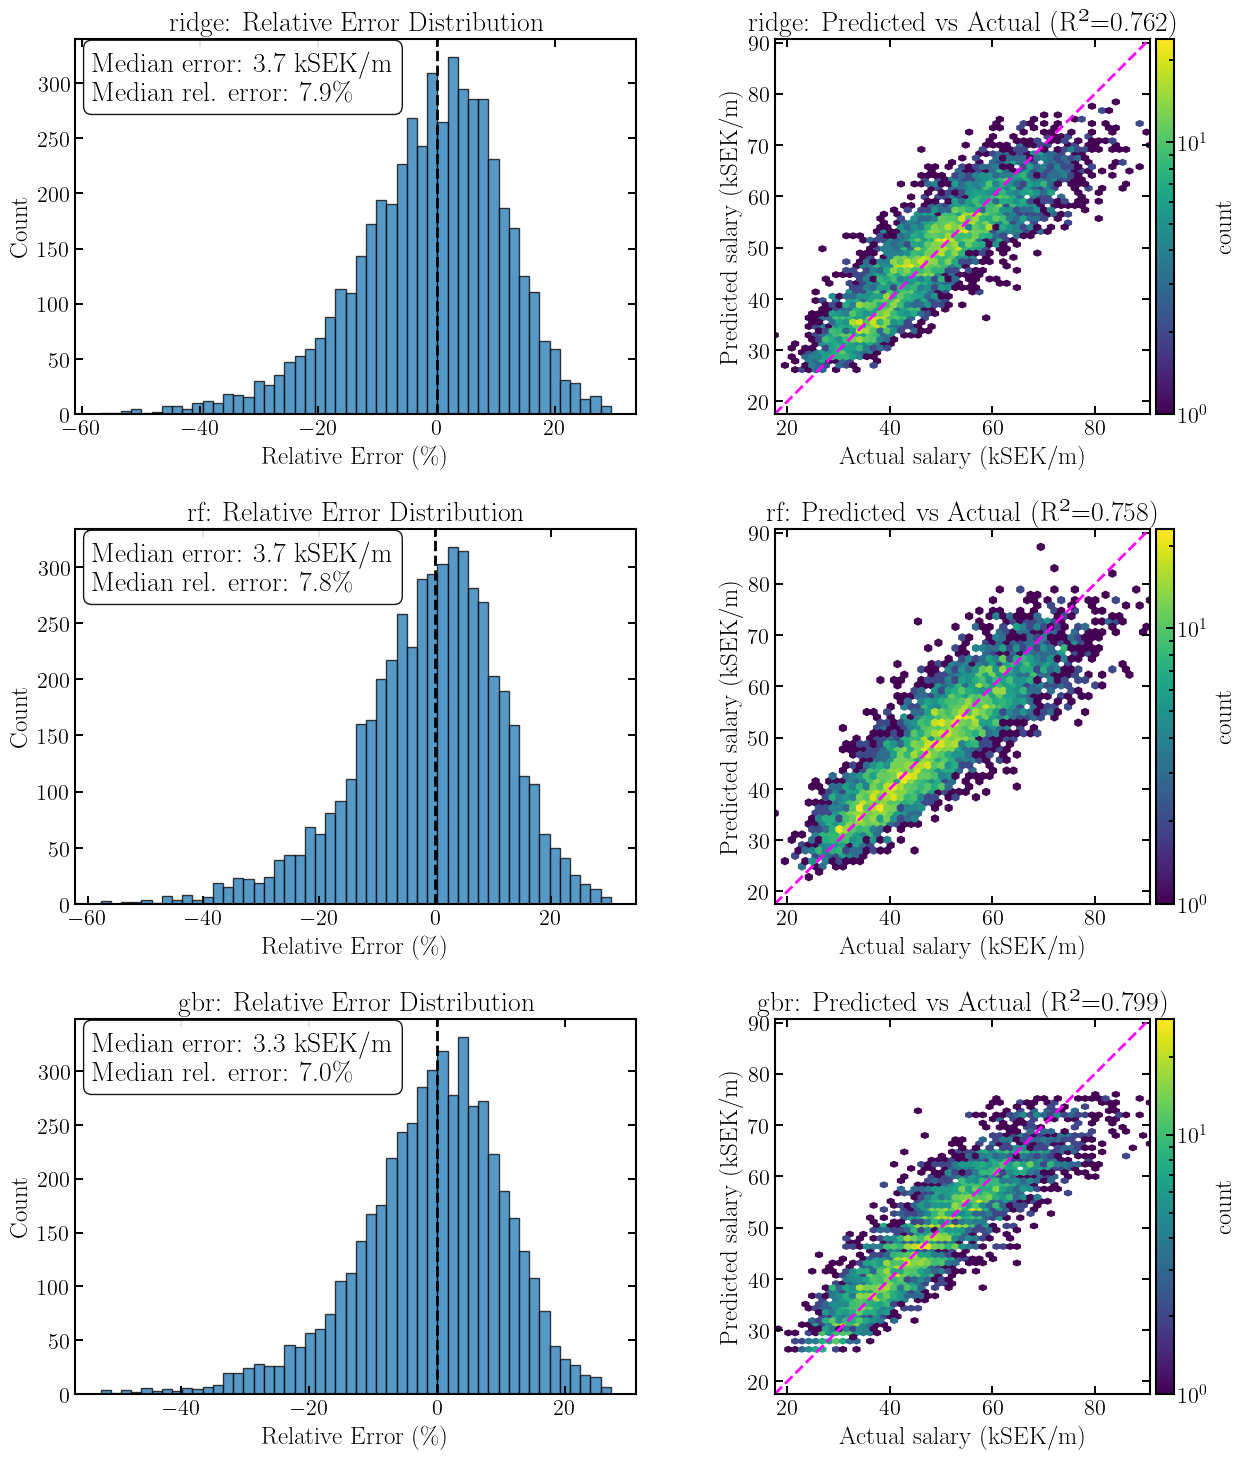

In [11]:
# Calculate and store the predictions
predictions = {}
for name, pipe in pipelines.items():
    predictions[name] = pipe.predict(X_test)

# Make the figure
fig, axes = plt.subplots(
    len(pipelines),
    2,
    figsize=(13, 5 * len(pipelines))
)

salary_min = min(y_test.min(), *(pred.min() for pred in predictions.values()))
salary_max = max(y_test.max(), *(pred.max() for pred in predictions.values()))

# Loop over models
for row, (name, y_pred) in enumerate(predictions.items()):

    residuals = y_test - y_pred
    relative_errors = 100 * residuals / y_test

    lower_clip = np.percentile(relative_errors, 0.1)
    upper_clip = np.percentile(relative_errors, 99.9)

    median_abs_error = np.median(np.abs(residuals))
    median_abs_relative_error = np.median(
        np.abs(relative_errors)
    )

    test_r2 = r2_score(y_test, y_pred)

    # Left panels: relative error distribution
    ax = axes[row, 0]

    ax.hist(
        relative_errors,
        bins=50,
        range=(lower_clip, upper_clip),
        alpha=0.75,
        edgecolor='black'
    )

    ax.axvline(
        0,
        linestyle='--',
        color='black',
        linewidth=2
    )

    ax.set_title(
        f"{name}: Relative Error Distribution"
    )

    ax.set_xlabel("Relative Error (\%)")
    ax.set_ylabel("Count")

    stats_text = (
        f"Median error: "
        f"{median_abs_error:.1f} kSEK/m\n"
        f"Median rel. error: "
        f"{median_abs_relative_error:.1f}\%"
    )

    ax.text(
        0.03,
        0.97,
        stats_text,
        transform=ax.transAxes,
        ha='left',
        va='top',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.9
        )
    )


    # Right panels: predicted vs actual
    ax = axes[row, 1]

    hb = ax.hexbin(
        y_test,
        y_pred,
        gridsize=55,
        bins='log',
        mincnt=1
    )

    min_val = min(
        y_test.min(),
        y_pred.min()
    )

    max_val = max(
        y_test.max(),
        y_pred.max()
    )

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle='--',
        color='magenta',
        linewidth=2
    )

    ax.set_title(
        f"{name}: Predicted vs Actual "
        f"(R²={test_r2:.3f})"
    )

    ax.set_xlabel("Actual salary (kSEK/m)")
    ax.set_ylabel("Predicted salary (kSEK/m)")

    ax.set_aspect('equal')

    cb = fig.colorbar(
        hb,
        ax=ax,
        pad=0.01
    )
    cb.set_label("count")

    ax.set_xlim(salary_min, salary_max)
    ax.set_ylim(salary_min, salary_max)

plt.tight_layout()
plt.show()

### Gain insight on how the models perform in different categories

In [12]:
workarea_results = {}
experience_results = {}

experience_bins = [0, 2, 5, 10, 20, 50]

for name, pipe in pipelines.items():

    y_pred = pipe.predict(X_test)

    error_df = pd.DataFrame({
        "actual": y_test,
        "predicted": y_pred,
        "work_area": X_test["work_area"],
        "experience": X_test["years_of_experience"]
    })

    error_df["abs_rel_error"] = (
        100 *
        np.abs(error_df["actual"] - error_df["predicted"])
        / error_df["actual"]
    )

    # Work area
    workarea_results[name] = (
        error_df
        .groupby("work_area")["abs_rel_error"]
        .median()
    )

    # Experience bins
    error_df["experience_bin"] = pd.cut(
        error_df["experience"],
        bins=experience_bins,
        labels=["0-2", "2-5", "5-10", "10-20", "20+"],
        include_lowest=True
    )

    experience_results[name] = (
        error_df
        .groupby("experience_bin")["abs_rel_error"]
        .median()
    )

workarea_results = pd.DataFrame(workarea_results)
experience_results = pd.DataFrame(experience_results)

#### Performance by work area

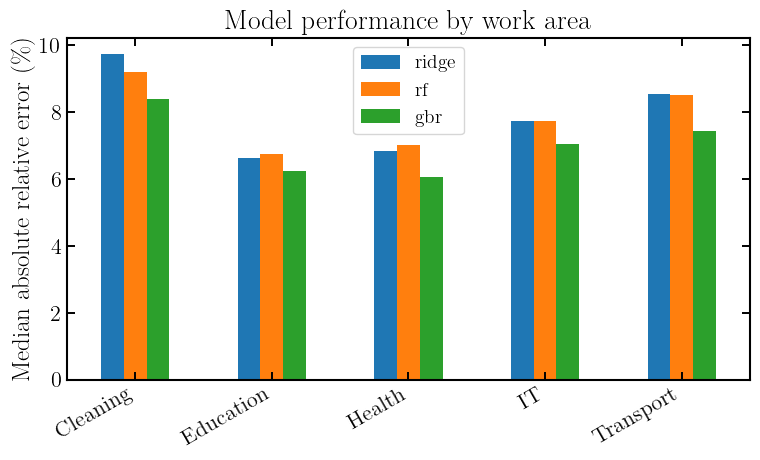

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(8,5))

workarea_results.plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel("Median absolute relative error (\%)")
ax.set_xlabel("")
ax.set_title("Model performance by work area")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### Performance by work experience

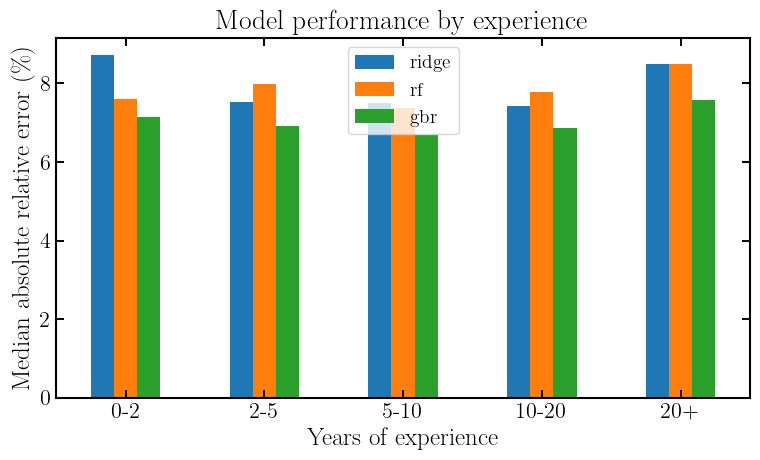

In [14]:
# Plot
fig, ax = plt.subplots(figsize=(8,5))

experience_results.plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel("Median absolute relative error (\%)")
ax.set_xlabel("Years of experience")
ax.set_title("Model performance by experience")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Final experiment: uncertainty estimate of the RF model

In [15]:
# =========================================================
# 1. Extract model + preprocess
# =========================================================

pipe_rf = pipelines["rf"]
rf_model = pipe_rf.named_steps["model"]
preprocess = pipe_rf.named_steps["preprocess"]

X_test_processed = preprocess.transform(X_test)

# =========================================================
# 2. Tree-level predictions
# =========================================================

tree_preds = np.vstack([
    tree.predict(X_test_processed)
    for tree in rf_model.estimators_
])

# =========================================================
# 3. Mean + epistemic uncertainty
# =========================================================

y_pred = tree_preds.mean(axis=0)
sigma_pred = tree_preds.std(axis=0)
sigma_pred = np.clip(sigma_pred, 1e-6, None)
y_true = np.asarray(y_test)

# =========================================================
# 4. Residuals + normalized residuals
# =========================================================

residuals = y_pred - y_true
z = residuals / sigma_pred

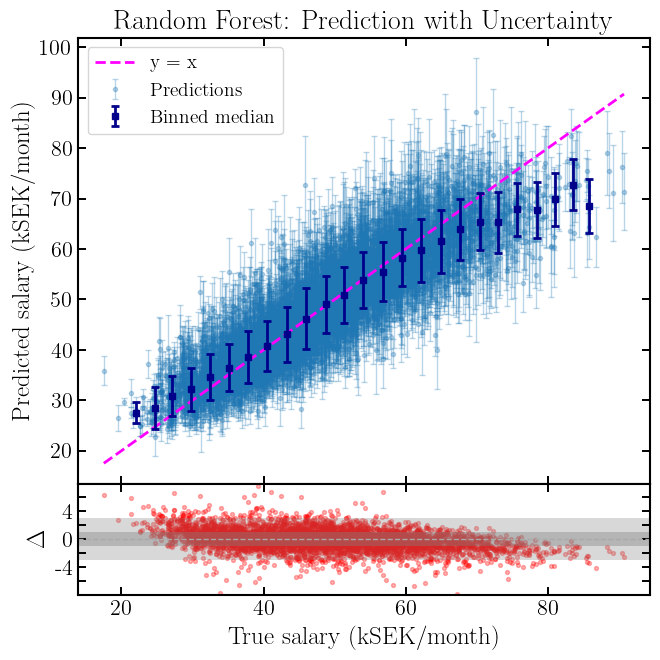

In [17]:
# =========================================================
# Figure layout
# =========================================================

# Create the main figure and axes
fig, ax = plt.subplots(figsize=(7, 7))

# Set labels and title
ax.set_ylabel("Predicted salary (kSEK/month)")
ax.set_title("Random Forest: Prediction with Uncertainty")

# =========================================================
# TOP: Predicted vs True with errorbars
# =========================================================

# Plot errorbars with y-errors (uncertainty from RF)
ax.errorbar(
    y_true,
    y_pred,
    yerr=sigma_pred,
    fmt='o',
    color='C0',
    alpha=0.3,
    markersize=3,
    elinewidth=1,
    capsize=2,
    label='Predictions'
)

# Plot the 1:1 line
min_v = min(y_true.min(), y_pred.min())
max_v = max(y_true.max(), y_pred.max())

ax.plot(
    [min_v, max_v],
    [min_v, max_v],
    linestyle='--',
    color='magenta',
    linewidth=2,
    label='y = x',
    zorder=10
)


# Plot the median of the predictions:
# Define bins 
n_bins = 28  
bins = np.linspace(y_true.min(), y_true.max(), n_bins)
bin_indices = np.digitize(y_true, bins)

# Calculate median y_pred and std for each bin
x_binned = []
y_median = []
y_std = []
for i in range(1, len(bins)):
    mask = bin_indices == i
    if np.sum(mask) > 4:  # Only calculate if enough points in bin
        x_binned.append(np.mean(y_true[mask]))
        y_median.append(np.median(y_pred[mask]))
        y_std.append(np.std(y_pred[mask]))

# Plot the binned median line with errorbars (showing spread)
ax.errorbar(
    x_binned,
    y_median,
    yerr=y_std,
    fmt='s',
    color='darkblue',
    markersize=5,
    elinewidth=2,
    capsize=3,
    capthick=2,
    label='Binned median',
    zorder=12,
    alpha=0.99
)

ax.legend(loc='best')

# =========================================================
# BOTTOM: Residuals 
# =========================================================

# Create secondary axis for residuals below the main plot
divider = make_axes_locatable(ax)
residuals_ax = divider.append_axes("bottom", size="25%", pad=0) 

# Set labels and scales
residuals_ax.set_xlabel("True salary (kSEK/month)")
residuals_ax.set_ylabel(r"$\Delta$")

# Plot residuals
residuals_ax.scatter(
    y_true,
    z,
    s=8,
    alpha=0.3,
    color='red',
    marker='o'
)

# Add horizontal line at y=0
residuals_ax.axhline(0, linestyle='--', color='darkgrey', linewidth=1, zorder=2)

# Add shaded regions for ±1 and ±3 sigma 

# Get x-axis limits from the main plot
xmin, xmax = ax.get_xlim()

# Rectangle for ±1 sigma 
rect1 = Rectangle(
    (xmin, -1),
    xmax - xmin,
    2,
    linewidth=0,
    edgecolor='none',
    facecolor='grey',
    alpha=0.4,
    zorder=1,
)
residuals_ax.add_patch(rect1)

# Rectangle for ±3 sigma 
rect2 = Rectangle(
    (xmin, -3),
    xmax - xmin,
    6,
    linewidth=0,
    edgecolor='none',
    facecolor='grey',
    alpha=0.3,
    zorder=1,
)
residuals_ax.add_patch(rect2)

# Set y-axis limits and ticks
residuals_ax.set_ylim(-8, 8)
residuals_ax.set_yticks([-8, -6, -4, -2, 0, 2, 4, 6, 8])
residuals_ax.set_yticklabels(['', '', '-4', '', '0', '', '4', '', ''])

# Match x-axis limits with the main plot
residuals_ax.set_xlim(xmin, xmax)

# Plot
plt.tight_layout()
plt.savefig('../figs/prediction_vs_truth.png', dpi=250)
plt.show()